<Figure size 1000x500 with 0 Axes>

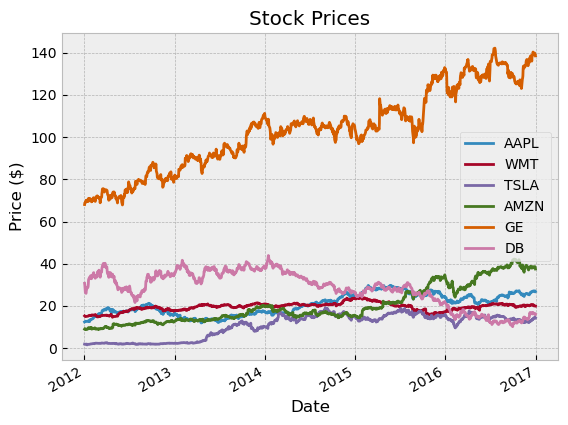

AAPL    0.154803
WMT     0.053214
TSLA    0.406862
AMZN    0.287153
GE      0.142554
DB     -0.130062
dtype: float64
          AAPL       WMT      TSLA      AMZN        GE        DB
AAPL  0.068351  0.008143  0.025434  0.019009  0.014196  0.024584
WMT   0.008143  0.028017  0.010265  0.008545  0.009221  0.013252
TSLA  0.025434  0.010265  0.252700  0.041774  0.019334  0.039072
AMZN  0.019009  0.008545  0.041774  0.094476  0.018026  0.031593
GE    0.014196  0.009221  0.019334  0.018026  0.032647  0.031366
DB    0.024584  0.013252  0.039072  0.031593  0.031366  0.139190


In [25]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.optimize as optim
import os

plt.style.use("bmh")

# on average there are 252 trading days in a year
NUM_TRADING_DAYS = 252

# stocks we are going to handle
stocks = ['AAPL', 'WMT', 'TSLA', 'AMZN', 'GE', 'DB']
# historical data - def start & end dates
start_date = '2012-01-01'
end_date = '2017-01-01'

# Create directories if they don't exist
os.makedirs('./data', exist_ok=True)
os.makedirs('./figs', exist_ok=True)

def download_data():
    stock_data = {} # name of the stock (key) - stock values 2010 - 2017 (values)
    for stock in stocks:
        ticker = yf.Ticker(stock) 
        stock_data[stock] = ticker.history(start=start_date, end=end_date)['Close'] # closing prices
        
    return pd.DataFrame(stock_data)

def show_data(data):
    plt.figure(figsize=(10,5))
    data.plot()
    plt.title('Stock Prices')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.savefig('./figs/stock_prices.png')
    plt.show()

def calculate_return(data):
    # Normalization - to measure all variables in comparable metrics
    log_return = np.log(data/data.shift(1))
    return log_return[1:]

def show_statistics(returns):
    # Instead of daily we are after annual metrics
    print(returns.mean() * NUM_TRADING_DAYS)
    print(returns.cov() * NUM_TRADING_DAYS)
    
def show_mean_variance(returns, weights):
    portfolio_return = np.sum(returns.mean()*weights) * NUM_TRADING_DAYS # for annual return
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * NUM_TRADING_DAYS, weights)))
    print("Expected prtfolio mean (return): ", portfolio_return)
    print("Expected portfolio volatility (std): ", portfolio_volatility)

def generate_portfolios(returns):
    port
    
if __name__ == '__main__':
    dataset = download_data()
    # Save data to CSV
    dataset.to_csv('./data/markowitzExercise.csv')
    show_data(dataset)
    log_daily_returns = calculate_return(dataset) 
    show_statistics(log_daily_returns)